# Notebook 1: Data Ingestion and EDA
Goal: Load the massive raw dataset and identify patterns/bottlenecks.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, desc
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.json as paj
import os, pathlib

In [2]:
#os.environ['HADOOP_HOME'] = r'C:\hadoop'
#os.environ['PATH'] = r'C:\hadoop\bin;' + os.environ.get('PATH', '')
#os.environ['PYSPARK_SUBMIT_ARGS'] = '--driver-memory 8g pyspark-shell'
import os, subprocess
os.environ["JAVA_HOME"] = subprocess.check_output(
    ["/usr/libexec/java_home", "-v", "17"]
).decode().strip()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName('Amazon_Ingestion_EDA') \
    .config('spark.driver.memory', '8g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .getOrCreate()

print('Spark version:', spark.version)
print('Spark UI: http://localhost:4040')

26/05/08 17:54:22 WARN Utils: Your hostname, Nithyas-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 192.168.0.244 instead (on interface en0)
26/05/08 17:54:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/08 17:54:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.8
Spark UI: http://localhost:4040


In [3]:
import glob

data_files = [
    'data/Cell_Phones_and_Accessories.jsonl',
    'data/Video_Games.jsonl'
]
parquet_output_path = 'data/amazon_reviews.parquet'

# Check for actual .parquet files, not just the directory
existing_parquets = glob.glob(os.path.join(parquet_output_path, '*.parquet'))

if not existing_parquets:
    # Clean up any empty/partial directory from previous failed runs
    import shutil
    if os.path.exists(parquet_output_path):
        shutil.rmtree(parquet_output_path)
        print('Cleaned up incomplete parquet directory.')
    os.makedirs(parquet_output_path, exist_ok=True)

    for fpath in data_files:
        category = pathlib.Path(fpath).stem
        out_file = os.path.join(parquet_output_path, f'{category}.parquet')
        size_gb = os.path.getsize(fpath) / 1e9
        print(f'Converting {fpath} ({size_gb:.2f} GB) -> {out_file} ...')
        table = paj.read_json(fpath)
        pq.write_table(table, out_file, compression='snappy')
        written_gb = os.path.getsize(out_file) / 1e9
        print(f'  Done: {written_gb:.2f} GB written, {len(table):,} rows')

    print('All files converted to Parquet!')
else:
    print(f'Found {len(existing_parquets)} existing parquet file(s). Skipping conversion.')
    for f in existing_parquets:
        print(f'  {f} ({os.path.getsize(f)/1e9:.2f} GB)')

# ── Step 2: Spark reads Parquet via absolute file:// URI ──
abs_path = 'file:///' + os.path.abspath(parquet_output_path).replace('\\', '/')
print(f'\nLoading Parquet from: {abs_path}')
df = spark.read.parquet(abs_path)
total = df.count()
print(f'Total records loaded: {total:,}')
df.printSchema()

Found 1 existing parquet file(s). Skipping conversion.
  data/amazon_reviews.parquet/Video_Games.parquet (1.13 GB)

Loading Parquet from: file:////Users/nithya/Documents/GitHub/DATA228_Recommendation_system-/data/amazon_reviews.parquet


Total records loaded: 4,624,615
root
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- small_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- attachment_type: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [4]:
# 3. Rating Distribution
rating_distribution = df.groupBy('rating').count().orderBy('rating')
rating_distribution.show()

# Top 20 most reviewed products
top_products = df.groupBy('parent_asin').count().orderBy(desc('count')).limit(20)
top_products.show()

+------+-------+
|rating|  count|
+------+-------+
|   1.0| 589519|
|   2.0| 249878|
|   3.0| 340086|
|   4.0| 617251|
|   5.0|2827881|
+------+-------+



+-----------+-----+
|parent_asin|count|
+-----------+-----+
| B01N3ASPNV|18105|
| B0BN942894|17310|
| B077GG9D5D|15594|
| B000N5Z2L4|13329|
| B0086VPUHI|12100|
| B004RMK5QG|10256|
| B07YBXFDYN| 9430|
| B00BGA9WK2| 8089|
| B07V8YSBFG| 7844|
| B07CRX5X9T| 7570|
| B07YBWT3PK| 7202|
| B0C5K4M7WJ| 7118|
| B08LT6PT1X| 7092|
| B0883P3VSH| 6528|
| B00HTK1NCS| 6490|
| B00DB2BI8M| 6320|
| B081243BT6| 6315|
| B00C1TTF86| 6216|
| B087NNPYP3| 6090|
| B019WRM1IA| 6087|
+-----------+-----+



In [5]:
# 4. Customer Insights: Power Users (>50 reviews)
power_users = df.groupBy('user_id').count().filter(col('count') > 50)
print('Total Power Users (>50 reviews):', power_users.count())
power_users.orderBy(desc('count')).show()

print('Top 10 Viral Products:')
df.groupBy('parent_asin').count().orderBy(desc('count')).limit(10).show()

Total Power Users (>50 reviews): 668


+--------------------+-----+
|             user_id|count|
+--------------------+-----+
|AHJRJCJMK3XVV4BSP...|  664|
|AGMWACNMAG74AXBF7...|  596|
|AGIBXD3LM6HNDWWRT...|  469|
|AEWLQYBQDYWWUWK6U...|  425|
|AHEDJIDSPVYCB3GPR...|  346|
|AGKOL2ISXEZE6EIPP...|  306|
|AHY7NSZXW4IUPQ2E4...|  292|
|AHF2J7WG4CPDF2IOV...|  262|
|AENQ4UD7LRPE5DW5B...|  245|
|AFVOW2EKNL5O25KG6...|  233|
|AH47YOPCGAQVRBKZ5...|  220|
|AGWMT2QORZIH3ITWU...|  220|
|AGFSNYGS5FKRQKPYQ...|  215|
|AGUTKSIA7TDKIDLDE...|  214|
|AFL2R6GJV4EBL4MEY...|  213|
|AGJY444VSFTXWHXZU...|  213|
|AEAJGVYGMLBO7LRYA...|  212|
|AGIR72F44THTLBTB4...|  204|
|AHQAWNTSQSEM344GA...|  202|
|AHOS5VRRULNXENWF7...|  197|
+--------------------+-----+
only showing top 20 rows

Top 10 Viral Products:
+-----------+-----+
|parent_asin|count|
+-----------+-----+
| B01N3ASPNV|18105|
| B0BN942894|17310|
| B077GG9D5D|15594|
| B000N5Z2L4|13329|
| B0086VPUHI|12100|
| B004RMK5QG|10256|
| B07YBXFDYN| 9430|
| B00BGA9WK2| 8089|
| B07V8YSBFG| 7844|
| B07CRX5X9T| 7

In [6]:
# 5. Skew Detection
skew_df = df.groupBy('parent_asin').count().orderBy(desc('count'))
skew_df.describe().show()

+-------+--------------------+------------------+
|summary|         parent_asin|             count|
+-------+--------------------+------------------+
|  count|              137249|            137249|
|   mean|3.1734018962623763E9|33.695072459544335|
| stddev|3.2316981993740945E9|200.25540693524783|
|    min|          0007922582|                 1|
|    max|          B0CKR257MD|             18105|
+-------+--------------------+------------------+



/var/folders/lx/xs85kwbx05xdq4c0h7yy1rmm0000gn/T/ipykernel_84005/3556732914.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y='count', data=rating_pd, palette='viridis')


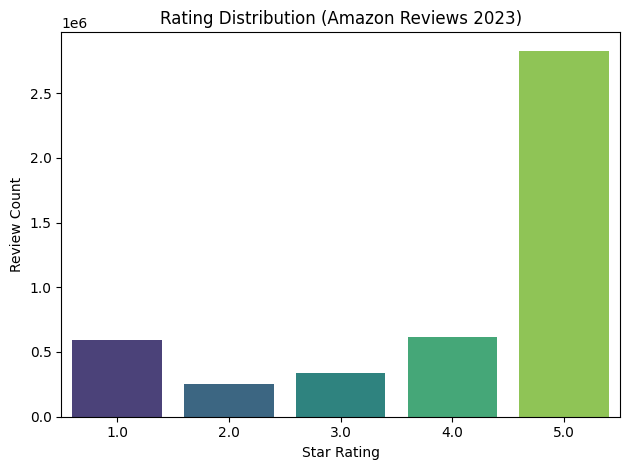

In [7]:
# 6. Visualizations
rating_pd = rating_distribution.toPandas()
sns.barplot(x='rating', y='count', data=rating_pd, palette='viridis')
plt.title('Rating Distribution (Amazon Reviews 2023)')
plt.xlabel('Star Rating')
plt.ylabel('Review Count')
plt.tight_layout()
plt.show()